1. Adquisición de datos:
Para este TP vamos a suponer que tenemos un instrumento que realiza una
medición cada cierto tiempo. El archivo “data_to_analyze.txt” contiene un cierto
número de mediciones realizadas que fueron almacenadas en forma de texto
plano. Estos son datos “raw” o sin procesar y se requiere realizar un módulo de
lectura de datos estos datos.

pruebaa

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame(pd.read_csv('data_to_analyze.txt', sep=','))

df.isna().sum()
df['data']=df['data'].fillna(0.0)
df.isna().sum()
df

,yy,mm,dd,time,data
0,2021,1,1,00:00,7.3
1,2021,1,1,00:10,7.5
2,2021,1,1,00:50,6.9
3,2021,1,1,01:00,6.4
4,2021,1,1,01:10,6.0
...,...,...,...,...,...
4386,2021,1,31,23:10,5.8
4387,2021,1,31,23:20,5.5
4388,2021,1,31,23:30,5.2
4389,2021,1,31,23:40,5.2


a. Determinar:
    i. Columnas que posee el set de datos.
    ii. Tipo de dato y dominio de cada columna.
Determinar: máximo valor, mínimo valor, media, mediana, moda, cantidad de
datos, desviación estándar

In [7]:
print('las columnas son: \n', df.columns)
print('los tipos son: \n', df.dtypes)
estadisticos= df.describe()
estadisticos= estadisticos.rename(index={'count': 'cantidad','mean': 'media','std':'varianza' })
for col in df.columns:
    print('El dominio de la columna ', col, ' es: \n', df[col].unique())


las columnas son: 
 Index(['yy', 'mm', 'dd', 'time', 'data'], dtype='object')
los tipos son: 
 yy        int64
mm        int64
dd        int64
time     object
data    float64
dtype: object
El dominio de la columna  yy  es: 
 [2021]
El dominio de la columna  mm  es: 
 [1]
El dominio de la columna  dd  es: 
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
El dominio de la columna  time  es: 
 ['00:00' '00:10' '00:50' '01:00' '01:10' '01:20' '01:30' '01:40' '01:50'
 '02:00' '02:10' '02:20' '02:30' '02:40' '02:50' '03:00' '03:10' '03:20'
 '03:30' '03:40' '03:50' '04:00' '04:10' '04:20' '04:30' '04:40' '04:50'
 '05:00' '05:10' '05:30' '05:40' '05:50' '06:00' '06:10' '06:20' '06:30'
 '06:40' '06:50' '07:00' '08:10' '08:20' '08:30' '08:40' '08:50' '09:00'
 '09:10' '09:20' '09:30' '09:40' '09:50' '10:00' '10:10' '10:20' '10:30'
 '10:40' '10:50' '11:00' '11:10' '11:20' '11:30' '11:40' '11:50' '12:00'
 '12:10' '12:20' '12:30' '12:40' '12:50' '13:00

¿Qué resolución poseen los datos? ¿Cuántos datos diarios se posee (en
teoría)? ¿Existen períodos donde la resolución varía?
Tenemos que los datos son medidos cada 10 minutos.
como se vio anteriormente, la columna data posee algunas mediciones vacias, es decir nulas, por ello si existen periodos donde la resolucion varia. Ademas que existen otros saltos mayores.

In [8]:
tiempo = pd.to_datetime(df[["yy","mm","dd"]].astype(str).agg("-".join, axis=1) + " " + df["time"])
tiempodif = tiempo.diff()
tiempodif.unique()

<TimedeltaArray>
[              NaT, '0 days 00:10:00', '0 days 00:40:00', '0 days 00:20:00',
 '0 days 01:10:00', '0 days 00:30:00', '0 days 00:50:00', '0 days 01:30:00',
 '0 days 01:40:00', '0 days 01:00:00', '0 days 01:50:00']
Length: 11, dtype: timedelta64[ns]

d. Eventualmente estos datos se deben comparar con datos que tienen una
resolución de 30 min. ¿Cómo podría solucionar el problema de diferentes
resoluciones? Utilizar alguna estrategia adecuada.
Se deberia hacer una limpieza de datos, por la cual al realizarse cada 10 minutos, es mejor hacer un algoritmo 
que obtenga la media de los datos que se obtenieron cada 10 minutos. Y para aquellos datos que son de 50 min, o mas se deberan considerar como nan. Dicha resolucion se llame resample. Otro caso que se podria hacer seria realizar una interpolacion de los datos, primero calculo la media cada 30 min y luego a los datos de 50 min lograr interporarlos a los mismos hasta llegar a 50 min y obtener los resultados en 30 min.

A aquellos datos que exceden los 30 min, como los de 50 min o los de 1 hora, al colocarlos en NaN se esta haciendo una Imputacion de datos Numericos.

In [9]:
df = df.set_index(tiempo)

# hacer resample a 30 minutos tomando el promedio
resample_30min = df["data"].resample("30T").mean()

#resample_30min


/tmp/ipykernel_89637/1947104634.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resample_30min = df["data"].resample("30T").mean()


Determinar el 1º, 2º y 3º cuartil. ¿Hay datos fuera de rango? Si es que los
hay, identificarlos.

In [12]:
cuartiles= df['data'].quantile([0.25, 0.5, 0.75])

Q1 = cuartiles[0.25]
Q3 = cuartiles[0.25]

inferior=Q1 - (1.5 * (Q3-Q1))
superior=Q3 + (1.5 * (Q3-Q1))

extremos = df[(df['data'] < inferior) | (df['data'] > superior)]

extremos['data']

2021-01-01 00:00:00    7.3
2021-01-01 00:10:00    7.5
2021-01-01 00:50:00    6.9
2021-01-01 01:00:00    6.4
2021-01-01 01:10:00    6.0
                      ... 
2021-01-31 23:10:00    5.8
2021-01-31 23:20:00    5.5
2021-01-31 23:30:00    5.2
2021-01-31 23:40:00    5.2
2021-01-31 23:50:00    5.2
Name: data, Length: 3144, dtype: float64

Graficar los datos. Observando el gráfico, existe alguna regularidad en los
datos (ciclos, tendencias).
El histograma realizo es respecto a la frecuencia de los datos en una clase, donde se agrupan los datos de a 12, debido a que es multiplo de la cantidad de datos contados. En este conjunto de datos se puede visualizar una distribucion simetrica con una tendencia alta en los primeros 12 datos y luego en el centro de el histograma

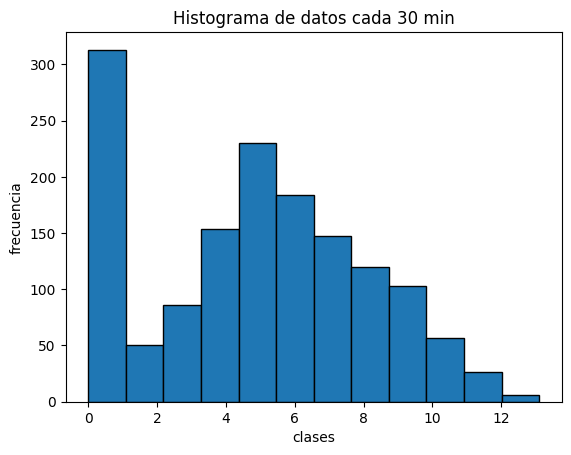

In [10]:
plt.hist(resample_30min, bins=12, edgecolor="black")
plt.xlabel("clases")
plt.ylabel("frecuencia")
plt.title("Histograma de datos cada 30 min")
plt.show()

Si tuviera que elegir un segmento de datos para generar un modelo con
algún algoritmo ¿Qué segmento elegiría? Justificar
Usaria los datos que se encuentran cada 30 min, es decir la media de los datos tomados con una frecuencia de 10 min. Si bien se perderian datos, ya que aquellos datos mayores a 30 min se pierden, se tiene una mayor presicion, ademas para simular como serian los datos en aquellas mediciones que se realizaron despues de 30 min, usaria interpolacion. 